# 04 – Target Engineering

Dieses Notebook untersucht die vierte Stufe des
Bitcoin-Price-Prediction-Projekts.

Voraussetzungen:

- `01_data_audit.ipynb` wurde erfolgreich ausgeführt.
- `02_eda.ipynb` wurde ausgewertet.
- `03_feature_engineering.ipynb` wurde ausgeführt.
- `target_engineering.py` hat den Target-Datensatz erzeugt.

Analysiert werden:

- zukünftige Log- und Simple-Returns,
- binäre Richtungstargets,
- DOWN/NEUTRAL/UP-Multiclass-Targets,
- zukünftige maximale und minimale Renditen,
- zukünftige realisierte Volatilität,
- zukünftiger maximaler Drawdown,
- exakte Target-Endzeitpunkte,
- unvollständige Zukunftsfenster,
- Datenlücken,
- Klassenverteilungen,
- zeitliche Stabilität,
- Alignment, Lokalität und Determinismus.

Features und Targets bleiben bewusst getrennt. Die Zusammenführung
erfolgt erst durch `dataset_builder.py`.

## 1. Umgebung und Imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.8f}",
)

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "target_engineering.py").exists()
        and (
            (path / "config.py").exists()
            or (path / "config_complete.py").exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook "
        "im Projektverzeichnis oder in einem Unterordner."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
except ImportError:
    from config_complete import SETTINGS

from target_engineering import (
    analyze_target_balance,
    build_target_frame,
    calculate_binary_targets,
    calculate_future_path_targets,
    calculate_future_return_targets,
    calculate_multiclass_targets,
    load_canonical_candles,
    target_dataset_overview,
    validate_determinism,
    validate_target_alignment,
    validate_target_frame,
    validate_target_horizons,
    validate_target_input,
    validate_target_locality,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(
    f"Symbol / Intervall: "
    f"{SETTINGS.market.symbol} / {SETTINGS.market.interval}"
)
print(f"Matplotlib-Backend: {plt.get_backend()}")

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Symbol / Intervall: BTCUSDT / 15m
Matplotlib-Backend: inline


## 2. Parameter

In [2]:
CANDLE_DATA_PATH: Path | None = None
TARGET_DATA_PATH: Path | None = None

# False lädt den bereits produktiv erzeugten Target-Datensatz.
RECOMPUTE_FULL_TARGETS = False

# Die Prüfungen verwenden Stichproben und sind für die Freigabe wichtig.
RUN_SAFETY_TESTS = True

RECENT_CANDLES = 30 * 96
ALIGNMENT_SAMPLE_SIZE = 2_000

selected_horizons = tuple(
    int(value)
    for value in SETTINGS.targets.horizons_candles
)
primary_horizon = int(
    SETTINGS.targets.primary_horizon_candles
)
target_prefix = str(
    SETTINGS.targets.label_prefix
)
interval_delta = pd.Timedelta(
    minutes=int(SETTINGS.market.interval_minutes)
)

default_target_path = (
    Path(SETTINGS.paths.processed_dir)
    / "targets"
    / (
        f"{SETTINGS.market.symbol}_"
        f"{SETTINGS.market.interval}_targets.parquet"
    )
)
resolved_target_path = (
    TARGET_DATA_PATH or default_target_path
)

print("Horizonte:", selected_horizons)
print("Primärhorizont:", primary_horizon)
print("Target-Pfad:", resolved_target_path)
print("Targets neu berechnen:", RECOMPUTE_FULL_TARGETS)

Horizonte: (1, 4, 16, 96)
Primärhorizont: 4
Target-Pfad: /home/milan/uni/python/BTC TSP/BTC TSP 15min/data/processed/targets/BTCUSDT_15m_targets.parquet
Targets neu berechnen: False


## 3. Candles laden und Qualitätsgate prüfen

In [3]:
candle_df = load_canonical_candles(
    SETTINGS,
    data_path=CANDLE_DATA_PATH,
)

quality_report = validate_target_input(
    candle_df,
    SETTINGS,
    horizons=selected_horizons,
)

quality_summary = pd.DataFrame(
    [
        {
            "status": quality_report.status,
            "is_valid": quality_report.is_valid,
            "rows": quality_report.row_count,
            "first_open_time": (
                quality_report.first_open_time
            ),
            "last_open_time": (
                quality_report.last_open_time
            ),
            "errors": len(quality_report.errors),
            "warnings": len(quality_report.warnings),
        }
    ]
)

display(quality_summary)

if quality_report.warnings:
    display(
        pd.DataFrame(
            {"warning": quality_report.warnings}
        )
    )

if not quality_report.is_valid:
    raise RuntimeError(quality_report.summary)

print("Candle-Datenqualitätsgate bestanden.")

,status,is_valid,rows,first_open_time,last_open_time,errors,warnings
0,warning,True,230106,2020-01-01T00:00:00+00:00,2026-07-26T12:15:00+00:00,0,7


,warning
0,13 Zeile(n) enthalten ein Volumen von 0.
1,13 Zeile(n) enthalten 0 Trades.
2,1 Zeile(n) haben eine logisch ungültige Bezieh...
3,6 Zeile(n) enden mehr als 5 Sekunden vor dem e...
4,152 Kerze(n) fehlen; größte Lücke: 23 Kerze(n).
5,1 Rendite(n) überschreiten den Warnschwellenwe...
6,4294 Volumenwert(e) überschreiten den robusten...


Candle-Datenqualitätsgate bestanden.


## 4. Targetkonfiguration

Für 15-Minuten-Kerzen entsprechen die Standardhorizonte:

| Kerzen | Zeitspanne |
|---:|---:|
| 1 | 15 Minuten |
| 4 | 1 Stunde |
| 16 | 4 Stunden |
| 96 | 24 Stunden |

In [4]:
target_configuration = pd.DataFrame(
    [
        (
            "primary_task",
            getattr(
                SETTINGS.targets.primary_task,
                "value",
                SETTINGS.targets.primary_task,
            ),
        ),
        (
            "horizons_candles",
            selected_horizons,
        ),
        (
            "primary_horizon_candles",
            primary_horizon,
        ),
        (
            "reference_price",
            SETTINGS.targets.reference_price,
        ),
        (
            "return_type",
            SETTINGS.targets.return_type,
        ),
        (
            "binary_threshold",
            SETTINGS.targets.binary_threshold,
        ),
        (
            "multiclass_down_threshold",
            SETTINGS.targets.multiclass_down_threshold,
        ),
        (
            "multiclass_up_threshold",
            SETTINGS.targets.multiclass_up_threshold,
        ),
        (
            "neutral_class_enabled",
            SETTINGS.targets.neutral_class_enabled,
        ),
        (
            "volatility_window_candles",
            SETTINGS.targets.volatility_window_candles,
        ),
        (
            "drop_rows_without_future_target",
            SETTINGS.targets.drop_rows_without_future_target,
        ),
    ],
    columns=["parameter", "value"],
)

horizon_table = pd.DataFrame(
    {
        "horizon_candles": selected_horizons,
        "horizon_minutes": [
            horizon
            * int(SETTINGS.market.interval_minutes)
            for horizon in selected_horizons
        ],
        "horizon_hours": [
            horizon
            * int(SETTINGS.market.interval_minutes)
            / 60
            for horizon in selected_horizons
        ],
    }
)

display(target_configuration)
display(horizon_table)

,parameter,value
0,primary_task,binary_classification
1,horizons_candles,"(1, 4, 16, 96)"
2,primary_horizon_candles,4
3,reference_price,close
4,return_type,log
5,binary_threshold,0.00100000
6,multiclass_down_threshold,-0.00100000
7,multiclass_up_threshold,0.00100000
8,neutral_class_enabled,True
9,volatility_window_candles,16


,horizon_candles,horizon_minutes,horizon_hours
0,1,15,0.25000000
1,4,60,1.00000000
2,16,240,4.00000000
3,96,1440,24.00000000


## 5. Target-Datensatz laden oder neu berechnen

In [5]:
if (
    RECOMPUTE_FULL_TARGETS
    or not resolved_target_path.exists()
):
    target_df = build_target_frame(
        candle_df,
        SETTINGS,
        horizons=selected_horizons,
        drop_incomplete=True,
    )
    target_source = "im Notebook neu berechnet"
else:
    target_df = pd.read_parquet(
        resolved_target_path
    )
    target_source = str(
        resolved_target_path.resolve()
    )

target_df["open_time"] = pd.to_datetime(
    target_df["open_time"],
    utc=True,
)

end_time_columns = [
    column
    for column in target_df.columns
    if column.startswith(
        f"{target_prefix}_end_time_"
    )
]

for column in end_time_columns:
    target_df[column] = pd.to_datetime(
        target_df[column],
        utc=True,
    )

value_target_columns = [
    column
    for column in target_df.columns
    if column.startswith(f"{target_prefix}_")
    and column not in end_time_columns
]

overview = pd.DataFrame(
    [
        {
            "Quelle": target_source,
            "Candle-Zeilen": len(candle_df),
            "Target-Zeilen": len(target_df),
            "Entfernte Zeilen": (
                len(candle_df) - len(target_df)
            ),
            "Spalten": len(target_df.columns),
            "Werttargets": len(value_target_columns),
            "Beginn": target_df["open_time"].min(),
            "Ende": target_df["open_time"].max(),
            "Speicher MiB": (
                target_df.memory_usage(
                    deep=True
                ).sum()
                / 2**20
            ),
        }
    ]
)

display(overview)
display(target_df.head(3))
display(target_df.tail(3))

,Quelle,Candle-Zeilen,Target-Zeilen,Entfernte Zeilen,Spalten,Werttargets,Beginn,Ende,Speicher MiB
0,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,230106,228570,1536,47,40,2020-01-01 00:00:00+00:00,2026-07-25 12:15:00+00:00,73.67781830


,symbol,interval,open_time,target_end_time_1,target_return_1,target_return_log_1,target_return_simple_1,target_binary_1,target_multiclass_1,target_future_max_return_1,target_future_min_return_1,target_future_realized_volatility_1,target_future_realized_volatility_annualized_1,target_future_max_drawdown_1,target_end_time_4,target_return_4,target_return_log_4,target_return_simple_4,target_binary_4,target_multiclass_4,target_future_max_return_4,target_future_min_return_4,target_future_realized_volatility_4,target_future_realized_volatility_annualized_4,target_future_max_drawdown_4,target_end_time_16,target_return_16,target_return_log_16,target_return_simple_16,target_binary_16,target_multiclass_16,target_future_max_return_16,target_future_min_return_16,target_future_realized_volatility_16,target_future_realized_volatility_annualized_16,target_future_max_drawdown_16,target_end_time_96,target_return_96,target_return_log_96,target_return_simple_96,target_binary_96,target_multiclass_96,target_future_max_return_96,target_future_min_return_96,target_future_realized_volatility_96,target_future_realized_volatility_annualized_96,target_future_max_drawdown_96
0,BTCUSDT,15m,2020-01-01 00:00:00+00:00,2020-01-01 00:15:00+00:00,-0.00035099,-0.00035099,-0.00035093,0,0,-0.00035093,-0.00035093,0.00035099,0.06570156,-0.00035093,2020-01-01 01:00:00+00:00,0.00137630,0.00137630,0.00137725,1,1,0.00137725,-0.00055006,0.00199594,0.18680996,-0.00055006,2020-01-01 04:00:00+00:00,0.00529443,0.00529443,0.00530848,1,1,0.00861722,-0.00055006,0.00563774,0.26383180,-0.00328048,2020-01-02 00:00:00+00:00,0.00200468,0.00200468,0.00200669,1,1,0.00896815,-0.00055006,0.01229883,0.23496891,-0.00837638
1,BTCUSDT,15m,2020-01-01 00:15:00+00:00,2020-01-01 00:30:00+00:00,0.00015462,0.00015462,0.00015463,0,0,0.00015463,0.00015463,0.00015462,0.02894282,0.00000000,2020-01-01 01:15:00+00:00,0.00467669,0.00467669,0.00468764,1,1,0.00468764,-0.00019921,0.00354394,0.33169484,-0.00035378,2020-01-01 04:15:00+00:00,0.00608029,0.00608029,0.00609881,1,1,0.00897130,-0.00019921,0.00564358,0.26410522,-0.00328048,2020-01-02 00:15:00+00:00,0.00281558,0.00281558,0.00281955,1,1,0.00932235,-0.00019921,0.01230242,0.23503750,-0.00837638
2,BTCUSDT,15m,2020-01-01 00:30:00+00:00,2020-01-01 00:45:00+00:00,-0.00035384,-0.00035384,-0.00035378,0,0,-0.00035378,-0.00035378,0.00035384,0.06623610,-0.00035378,2020-01-01 01:30:00+00:00,0.00449018,0.00449018,0.00450028,1,1,0.00453231,-0.00035378,0.00354071,0.33139245,-0.00035378,2020-01-01 04:30:00+00:00,0.00588275,0.00588275,0.00590008,1,1,0.00881530,-0.00035378,0.00564163,0.26401373,-0.00328048,2020-01-02 00:30:00+00:00,0.00387711,0.00387711,0.00388464,1,1,0.00916630,-0.00035378,0.01236142,0.23616465,-0.00837638


,symbol,interval,open_time,target_end_time_1,target_return_1,target_return_log_1,target_return_simple_1,target_binary_1,target_multiclass_1,target_future_max_return_1,target_future_min_return_1,target_future_realized_volatility_1,target_future_realized_volatility_annualized_1,target_future_max_drawdown_1,target_end_time_4,target_return_4,target_return_log_4,target_return_simple_4,target_binary_4,target_multiclass_4,target_future_max_return_4,target_future_min_return_4,target_future_realized_volatility_4,target_future_realized_volatility_annualized_4,target_future_max_drawdown_4,target_end_time_16,target_return_16,target_return_log_16,target_return_simple_16,target_binary_16,target_multiclass_16,target_future_max_return_16,target_future_min_return_16,target_future_realized_volatility_16,target_future_realized_volatility_annualized_16,target_future_max_drawdown_16,target_end_time_96,target_return_96,target_return_log_96,target_return_simple_96,target_binary_96,target_multiclass_96,target_future_max_return_96,target_future_min_return_96,target_future_realized_volatility_96,target_future_realized_volatility_annualized_96,target_future_max_drawdown_96
228567,BTCUSDT,15m,2026-07-25 11:45:00+00:00,2026-07-25 12:00:00+00:00,-0.00003122,-0.00003122,-0.00003122,0,0,-0.00003122,-0.00003122,0.00003122,0.00584393,-0.00003122,2026-07-25 12:45:00+00:00,0.00093285,0.00093285,0.00093329,0,0,0.00093329,-0.00021869,0.00085072,0.07962301,-0.00021869,2026-07-25 15:45:00+00:00,0.00184006,0.00184006,0.00184175,1,1,0.00282733,-0.00021869,0.00188240,0.08809139,-0.00098280,2026-07-26 11:45:00+00:00,0.00689643,0.00689643,0.00692027,1,1,0.00805398,-0.00021869,0.00553948,0.10583171,-0.00430815
228568,BTCUSDT,15m,2026-07-25 12:00:00+00:00,2026-07-25 12:15:00+00:00,-0.00018749,-0.00018749,-0.00018747,0,0,-0.00018747,-0.00018747,0.00018749,0.03509661,-0.00018747,2026-07-25 13:00:00+00:00,0.00107588,0.00107588,0.00107646,1,1,0.00107646,-0.00018747,0.00085747,0.08025457,-0.00018747,2026-07-25 16:00:00+00:00,0.00227629,0.00227629,0.00227889,1,1,0.00285864,-0.00018747,0.00192522,0.09009552,-0.00098280,2026-07-26 12:00:00+00:00,0.00850235,0.00850235,0.00853860,1,1,0.00853860,-0.00018747,0.00575887,0.11002310,-0.00430815
228569,BTCUSDT,15m,2026-07-25 12:15:00+00:00,2026-07-25 12:30:00+00:00,0.00068657,0.00068657,0.00068681,0,0,0.00068681,0.00068681,0.00068657,0.12851913,0.00000000,2026-07-25 13:15:00+00:00,0.00127943,0.00127943,0.00128025,1,1,0.00128025,0.00068681,0.00083687,0.07832696,0.00000000,2026-07-25 16:15:00+00:00,0.00143940,0.00143940,0.00144044,1,1,0.00304668,0.00068681,0.00217272,0.10167754,-0.00160137,2026-07-26 12:15:00+00:00,0.00812955,0.00812955,0.00816269,1,1,0.00872771,0.00068681,0.00578303,0.11048455,-0.00430815


## 6. Vollständige Targetvalidierung

In [6]:
target_report = validate_target_frame(
    target_df,
    SETTINGS,
    horizons=selected_horizons,
    require_complete_targets=True,
)

display(pd.DataFrame([target_report.to_dict()]))

if target_report.warnings:
    display(
        pd.DataFrame(
            {"warning": target_report.warnings}
        )
    )

if not target_report.is_valid:
    raise RuntimeError(target_report.summary)

print("Target-Datensatz vollständig validiert.")

,generated_at,row_count,column_count,target_count,selected_horizons,first_open_time,last_open_time,duplicate_key_rows,unsorted,non_numeric_target_columns,infinite_counts,missing_counts,invalid_binary_values,invalid_multiclass_values,invalid_end_time_rows,errors,warnings
0,2026-07-27T18:35:17.567021+00:00,228570,47,40,"[1, 4, 16, 96]",2020-01-01T00:00:00+00:00,2026-07-25T12:15:00+00:00,0,False,[],{},{},{},{},{},[],[]


Target-Datensatz vollständig validiert.


## 7. Targetkatalog

In [7]:
expected_target_rows = []

for horizon in selected_horizons:
    definitions = {
        "end_time": (
            f"{target_prefix}_end_time_{horizon}"
        ),
        "configured_return": (
            f"{target_prefix}_return_{horizon}"
        ),
        "log_return": (
            f"{target_prefix}_return_log_{horizon}"
        ),
        "simple_return": (
            f"{target_prefix}_return_simple_{horizon}"
        ),
        "binary": (
            f"{target_prefix}_binary_{horizon}"
        ),
        "multiclass": (
            f"{target_prefix}_multiclass_{horizon}"
        ),
        "future_max_return": (
            f"{target_prefix}_future_max_return_{horizon}"
        ),
        "future_min_return": (
            f"{target_prefix}_future_min_return_{horizon}"
        ),
        "future_realized_volatility": (
            f"{target_prefix}_future_realized_volatility_"
            f"{horizon}"
        ),
        "future_realized_volatility_annualized": (
            f"{target_prefix}_future_realized_volatility_"
            f"annualized_{horizon}"
        ),
        "future_max_drawdown": (
            f"{target_prefix}_future_max_drawdown_{horizon}"
        ),
    }

    for target_type, column in definitions.items():
        expected_target_rows.append(
            {
                "horizon": horizon,
                "target_type": target_type,
                "column": column,
                "exists": column in target_df.columns,
                "dtype": (
                    str(target_df[column].dtype)
                    if column in target_df.columns
                    else None
                ),
                "missing": (
                    int(target_df[column].isna().sum())
                    if column in target_df.columns
                    else None
                ),
            }
        )

target_catalog = pd.DataFrame(
    expected_target_rows
)

display(target_catalog)
assert target_catalog["exists"].all()

,horizon,target_type,column,exists,dtype,missing
0,1,end_time,target_end_time_1,True,"datetime64[us, UTC]",0
1,1,configured_return,target_return_1,True,float64,0
2,1,log_return,target_return_log_1,True,float64,0
3,1,simple_return,target_return_simple_1,True,float64,0
4,1,binary,target_binary_1,True,Int8,0
5,1,multiclass,target_multiclass_1,True,Int8,0
6,1,future_max_return,target_future_max_return_1,True,float64,0
7,1,future_min_return,target_future_min_return_1,True,float64,0
8,1,future_realized_volatility,target_future_realized_volatility_1,True,float64,0
9,1,future_realized_volatility_annualized,target_future_realized_volatility_annualized_1,True,float64,0


## 8. Exakte Target-Endzeitpunkte

Ein Target für Horizont `h` muss exakt bei

```text
open_time + h × Intervall
```

enden.

In [8]:
horizon_validation = validate_target_horizons(
    target_df,
    SETTINGS,
    horizons=selected_horizons,
)

horizon_checks = []

for horizon in selected_horizons:
    end_column = (
        f"{target_prefix}_end_time_{horizon}"
    )
    expected = (
        target_df["open_time"]
        + horizon * interval_delta
    )
    actual = target_df[end_column]

    mismatch = int(
        (
            actual.notna()
            & (actual != expected)
        ).sum()
    )

    horizon_checks.append(
        {
            "horizon": horizon,
            "expected_duration": (
                horizon * interval_delta
            ),
            "mismatch_count": mismatch,
            "validator_count": (
                horizon_validation[end_column]
            ),
            "passed": (
                mismatch == 0
                and horizon_validation[
                    end_column
                ] == 0
            ),
        }
    )

horizon_check_frame = pd.DataFrame(
    horizon_checks
)
display(horizon_check_frame)

assert horizon_check_frame["passed"].all()

,horizon,expected_duration,mismatch_count,validator_count,passed
0,1,0 days 00:15:00,0,0,True
1,4,0 days 01:00:00,0,0,True
2,16,0 days 04:00:00,0,0,True
3,96,1 days 00:00:00,0,0,True


## 9. Manuelle Renditeprüfung

Für eine Stichprobe werden Start- und Endpreis direkt aus dem
kanonischen Candle-Datensatz gelesen.

In [9]:
reference_price = str(
    SETTINGS.targets.reference_price
)

candle_lookup = candle_df[
    [
        "symbol",
        "interval",
        "open_time",
        reference_price,
    ]
].copy()

candle_lookup["open_time"] = pd.to_datetime(
    candle_lookup["open_time"],
    utc=True,
)

sample_positions = np.linspace(
    0,
    len(target_df) - 1,
    min(20, len(target_df)),
    dtype=int,
)

sample = target_df.iloc[
    sample_positions
].copy()

return_checks = []

for horizon in selected_horizons:
    end_column = (
        f"{target_prefix}_end_time_{horizon}"
    )
    log_column = (
        f"{target_prefix}_return_log_{horizon}"
    )
    simple_column = (
        f"{target_prefix}_return_simple_{horizon}"
    )

    check = sample[
        [
            "symbol",
            "interval",
            "open_time",
            end_column,
            log_column,
            simple_column,
        ]
    ].copy()

    start_prices = candle_lookup.rename(
        columns={
            reference_price: "start_price",
        }
    )

    check = check.merge(
        start_prices,
        on=[
            "symbol",
            "interval",
            "open_time",
        ],
        how="left",
        validate="many_to_one",
    )

    end_prices = candle_lookup.rename(
        columns={
            "open_time": end_column,
            reference_price: "end_price",
        }
    )

    check = check.merge(
        end_prices,
        on=[
            "symbol",
            "interval",
            end_column,
        ],
        how="left",
        validate="many_to_one",
    )

    check["manual_simple_return"] = (
        check["end_price"]
        / check["start_price"]
        - 1
    )
    check["manual_log_return"] = np.log(
        check["end_price"]
        / check["start_price"]
    )

    log_error = (
        check[log_column]
        - check["manual_log_return"]
    ).abs()
    simple_error = (
        check[simple_column]
        - check["manual_simple_return"]
    ).abs()

    return_checks.append(
        {
            "horizon": horizon,
            "checked_rows": len(check),
            "maximum_log_error": float(
                log_error.max()
            ),
            "maximum_simple_error": float(
                simple_error.max()
            ),
            "passed": (
                log_error.max() <= 1e-12
                and simple_error.max() <= 1e-12
            ),
        }
    )

return_check_frame = pd.DataFrame(
    return_checks
)
display(return_check_frame)

assert return_check_frame["passed"].all()

,horizon,checked_rows,maximum_log_error,maximum_simple_error,passed
0,1,20,0.00000000,0.00000000,True
1,4,20,0.00000000,0.00000000,True
2,16,20,0.00000000,0.00000000,True
3,96,20,0.00000000,0.00000000,True


## 10. Renditeverteilungen je Horizont

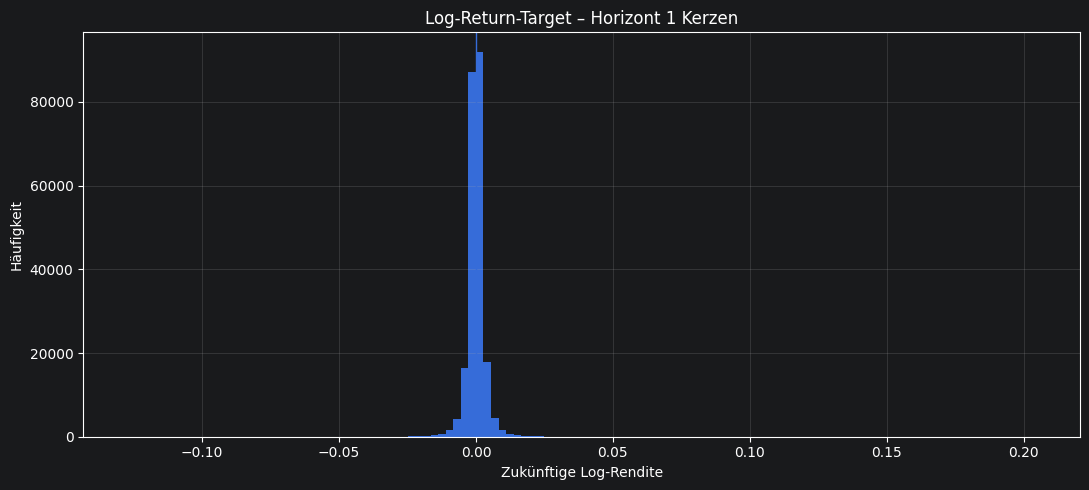

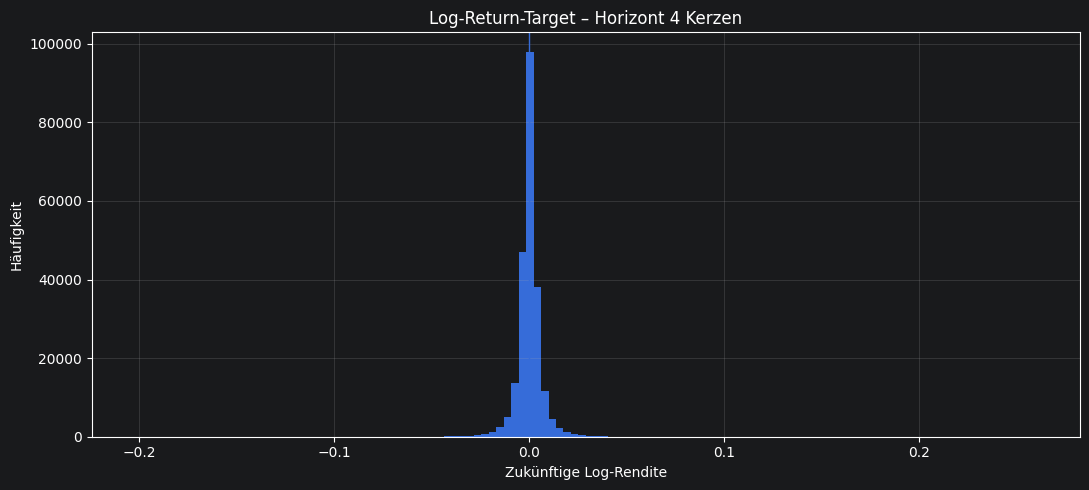

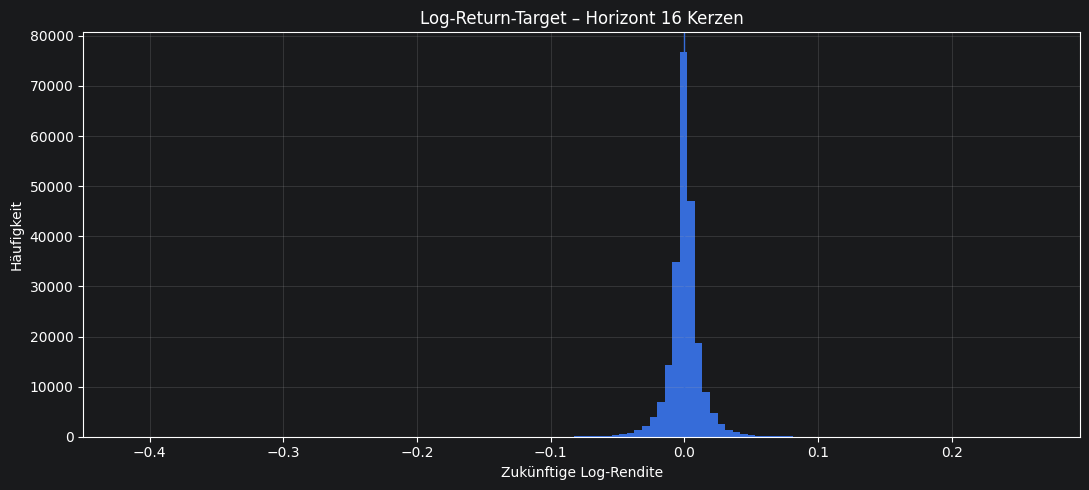

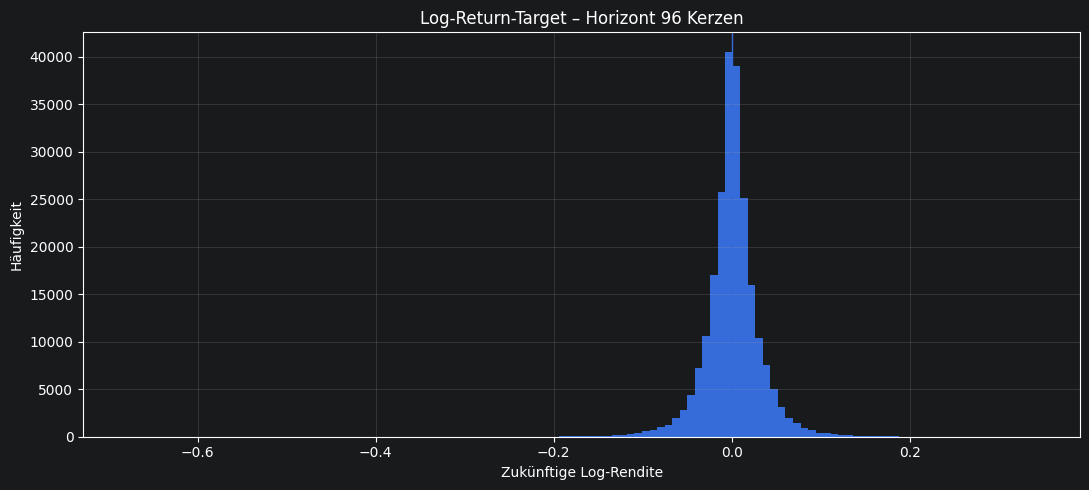

,horizon,count,mean,std,minimum,p01,p05,median,p95,p99,maximum,positive_ratio
0,1,228570,0.00000925,0.00338164,-0.12688927,-0.00944960,-0.00441095,0.00000954,0.00440910,0.00932667,0.20399154,0.50222251
1,4,228570,0.00003696,0.00661408,-0.20103321,-0.01915949,-0.00885187,0.00005362,0.00892451,0.01883833,0.25935472,0.50721005
2,16,228570,0.00014976,0.01286894,-0.41573787,-0.03819428,-0.01864844,0.00016944,0.01887121,0.03761239,0.26192310,0.51155007
3,96,228570,0.00085582,0.03138190,-0.67774671,-0.09067937,-0.04638264,0.00086132,0.04873797,0.08728304,0.34052502,0.52171764


In [10]:
return_statistics = []

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_return_log_{horizon}"
    )
    values = target_df[column].dropna()

    return_statistics.append(
        {
            "horizon": horizon,
            "count": len(values),
            "mean": float(values.mean()),
            "std": float(values.std()),
            "minimum": float(values.min()),
            "p01": float(values.quantile(0.01)),
            "p05": float(values.quantile(0.05)),
            "median": float(values.median()),
            "p95": float(values.quantile(0.95)),
            "p99": float(values.quantile(0.99)),
            "maximum": float(values.max()),
            "positive_ratio": float(
                (values > 0).mean()
            ),
        }
    )

    figure, axis = plt.subplots(
        figsize=(11, 5)
    )
    axis.hist(values, bins=120)
    axis.axvline(0, linewidth=1)
    axis.set_title(
        f"Log-Return-Target – Horizont "
        f"{horizon} Kerzen"
    )
    axis.set_xlabel("Zukünftige Log-Rendite")
    axis.set_ylabel("Häufigkeit")
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

return_statistics_frame = pd.DataFrame(
    return_statistics
)
display(return_statistics_frame)

## 11. Skalierung der Renditen mit dem Horizont

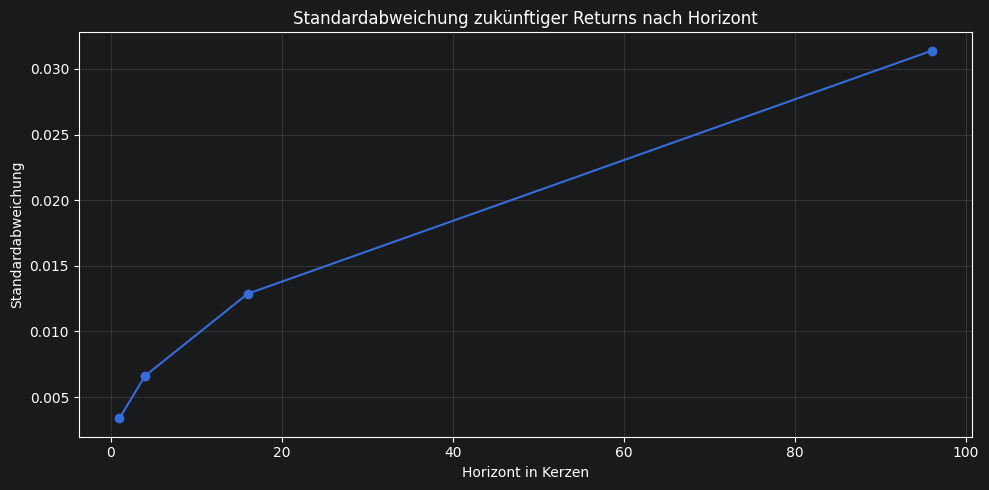

,horizon,std,sqrt_horizon,std_per_sqrt_horizon
0,1,0.00338164,1.00000000,0.00338164
1,4,0.00661408,2.00000000,0.00330704
2,16,0.01286894,4.00000000,0.00321723
3,96,0.03138190,9.79795897,0.00320290


In [11]:
figure, axis = plt.subplots(figsize=(10, 5))
axis.plot(
    return_statistics_frame["horizon"],
    return_statistics_frame["std"],
    marker="o",
)
axis.set_title(
    "Standardabweichung zukünftiger Returns "
    "nach Horizont"
)
axis.set_xlabel("Horizont in Kerzen")
axis.set_ylabel("Standardabweichung")
axis.grid(True, alpha=0.25)
figure.tight_layout()
display(figure)
plt.close(figure)

horizon_scaling = (
    return_statistics_frame[
        ["horizon", "std"]
    ].copy()
)
horizon_scaling["sqrt_horizon"] = np.sqrt(
    horizon_scaling["horizon"]
)
horizon_scaling["std_per_sqrt_horizon"] = (
    horizon_scaling["std"]
    / horizon_scaling["sqrt_horizon"]
)

display(horizon_scaling)

## 12. Binäre Klassenverteilung

,horizon,class,label,count,ratio
0,1,0,NOT_UP,161596,0.70698692
1,1,1,UP,66974,0.29301308
2,4,0,NOT_UP,140997,0.61686573
3,4,1,UP,87573,0.38313427
4,16,0,NOT_UP,126884,0.55512097
5,16,1,UP,101686,0.44487903
6,96,0,NOT_UP,115051,0.50335127
7,96,1,UP,113519,0.49664873


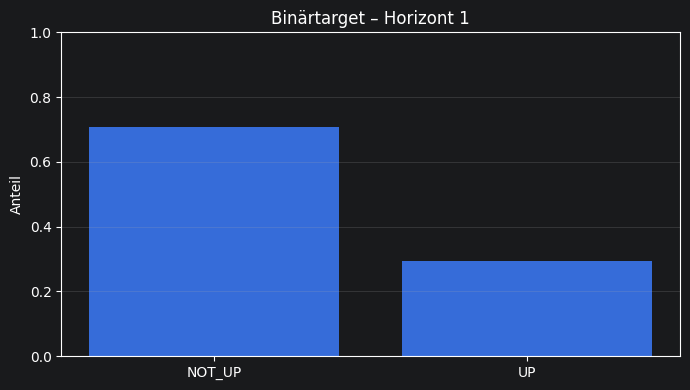

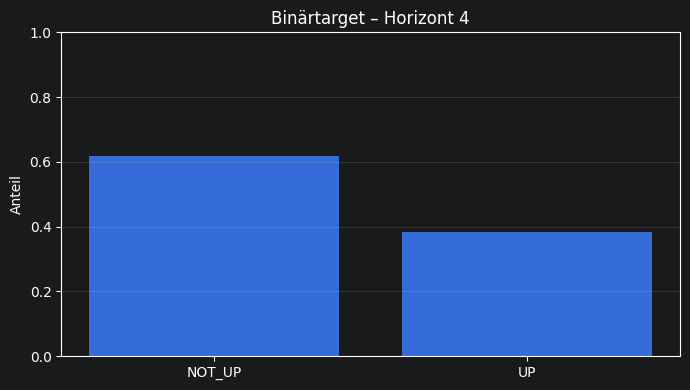

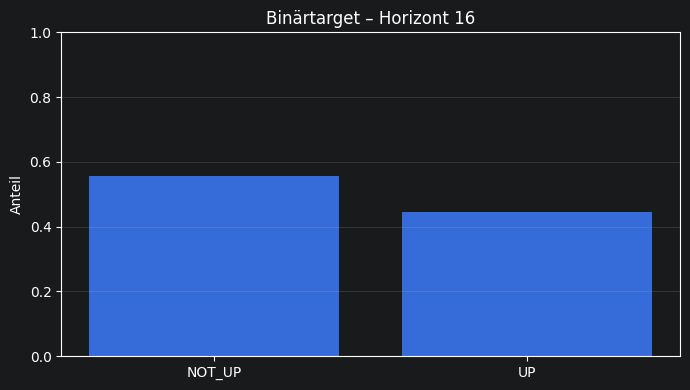

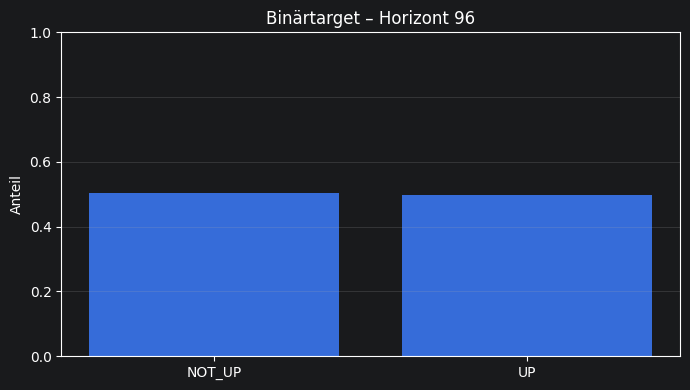

In [12]:
binary_rows = []

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_binary_{horizon}"
    )
    counts = (
        target_df[column]
        .value_counts(normalize=False)
        .sort_index()
    )
    ratios = (
        target_df[column]
        .value_counts(normalize=True)
        .sort_index()
    )

    for class_value in counts.index:
        binary_rows.append(
            {
                "horizon": horizon,
                "class": int(class_value),
                "label": (
                    "UP"
                    if int(class_value) == 1
                    else "NOT_UP"
                ),
                "count": int(
                    counts.loc[class_value]
                ),
                "ratio": float(
                    ratios.loc[class_value]
                ),
            }
        )

binary_balance = pd.DataFrame(binary_rows)
display(binary_balance)

for horizon in selected_horizons:
    current = binary_balance.loc[
        binary_balance["horizon"]
        == horizon
    ]

    figure, axis = plt.subplots(
        figsize=(7, 4)
    )
    axis.bar(
        current["label"],
        current["ratio"],
    )
    axis.set_title(
        f"Binärtarget – Horizont {horizon}"
    )
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 13. Multiclass-Verteilung

Kodierung:

- `-1`: DOWN
- `0`: NEUTRAL
- `1`: UP

,horizon,class,label,count,ratio
0,1,-1,DOWN,65593,0.28697117
1,1,0,NEUTRAL,96003,0.42001575
2,1,1,UP,66974,0.29301308
3,4,-1,DOWN,84326,0.36892856
4,4,0,NEUTRAL,56671,0.24793717
5,4,1,UP,87573,0.38313427
6,16,-1,DOWN,96575,0.42251827
7,16,0,NEUTRAL,30309,0.13260270
8,16,1,UP,101686,0.44487903
9,96,-1,DOWN,103791,0.45408846


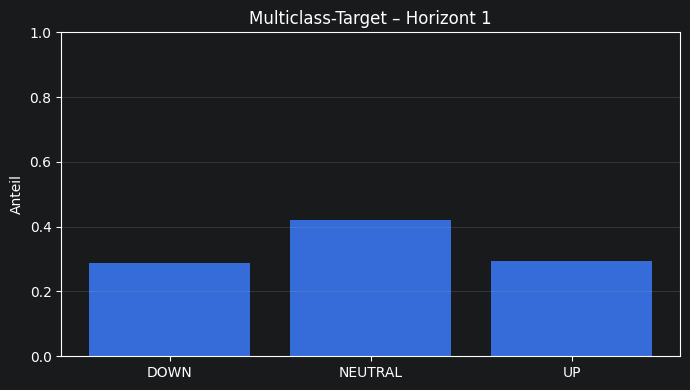

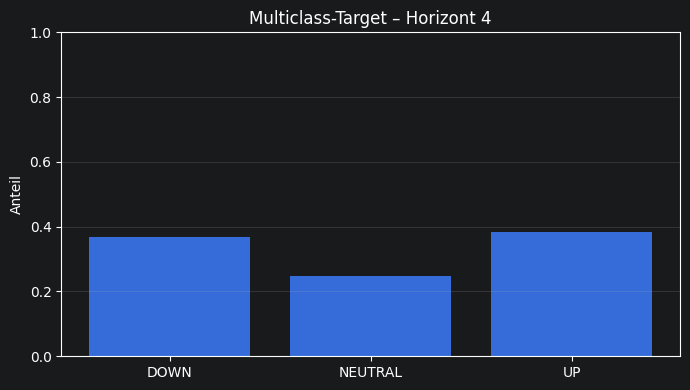

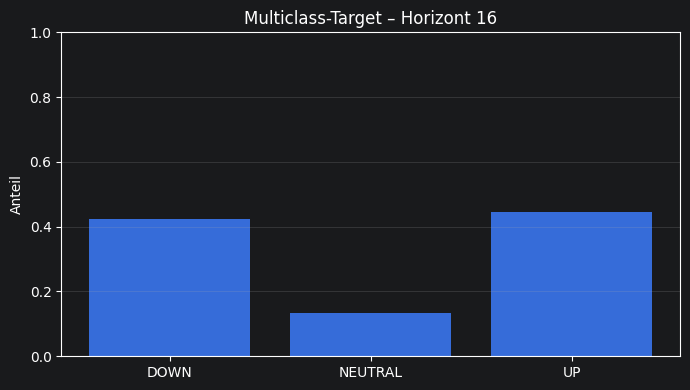

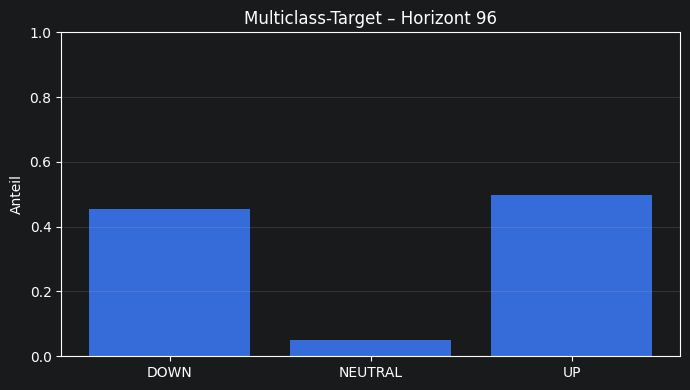

In [13]:
multiclass_labels = {
    -1: "DOWN",
    0: "NEUTRAL",
    1: "UP",
}

multiclass_rows = []

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_multiclass_{horizon}"
    )
    counts = (
        target_df[column]
        .value_counts(normalize=False)
        .sort_index()
    )
    ratios = (
        target_df[column]
        .value_counts(normalize=True)
        .sort_index()
    )

    for class_value in counts.index:
        value = int(class_value)

        multiclass_rows.append(
            {
                "horizon": horizon,
                "class": value,
                "label": multiclass_labels[value],
                "count": int(
                    counts.loc[class_value]
                ),
                "ratio": float(
                    ratios.loc[class_value]
                ),
            }
        )

multiclass_balance = pd.DataFrame(
    multiclass_rows
)
display(multiclass_balance)

for horizon in selected_horizons:
    current = multiclass_balance.loc[
        multiclass_balance["horizon"]
        == horizon
    ]

    figure, axis = plt.subplots(
        figsize=(7, 4)
    )
    axis.bar(
        current["label"],
        current["ratio"],
    )
    axis.set_title(
        f"Multiclass-Target – "
        f"Horizont {horizon}"
    )
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 14. Klassenverteilung nach Jahr

,target_type,horizon_candles,column,class,count,ratio_of_valid
0,binary,1,target_binary_1,0,161596,0.70698692
1,binary,1,target_binary_1,1,66974,0.29301308
2,multiclass,1,target_multiclass_1,-1,65593,0.28697117
3,multiclass,1,target_multiclass_1,0,96003,0.42001575
4,multiclass,1,target_multiclass_1,1,66974,0.29301308
5,binary,4,target_binary_4,0,140997,0.61686573
6,binary,4,target_binary_4,1,87573,0.38313427
7,multiclass,4,target_multiclass_4,-1,84326,0.36892856
8,multiclass,4,target_multiclass_4,0,56671,0.24793717
9,multiclass,4,target_multiclass_4,1,87573,0.38313427


,target_type,horizon_candles,column,year,class,count,ratio
0,binary,1,target_binary_1,2020,0,23369,0.68159015
1,binary,1,target_binary_1,2020,1,10917,0.31840985
2,binary,1,target_binary_1,2021,0,21413,0.62248903
3,binary,1,target_binary_1,2021,1,12986,0.37751097
4,binary,1,target_binary_1,2022,0,24573,0.70128425
5,binary,1,target_binary_1,2022,1,10467,0.29871575
6,binary,1,target_binary_1,2023,0,27089,0.77532271
7,binary,1,target_binary_1,2023,1,7850,0.22467729
8,binary,1,target_binary_1,2024,0,24466,0.69632286
9,binary,1,target_binary_1,2024,1,10670,0.30367714


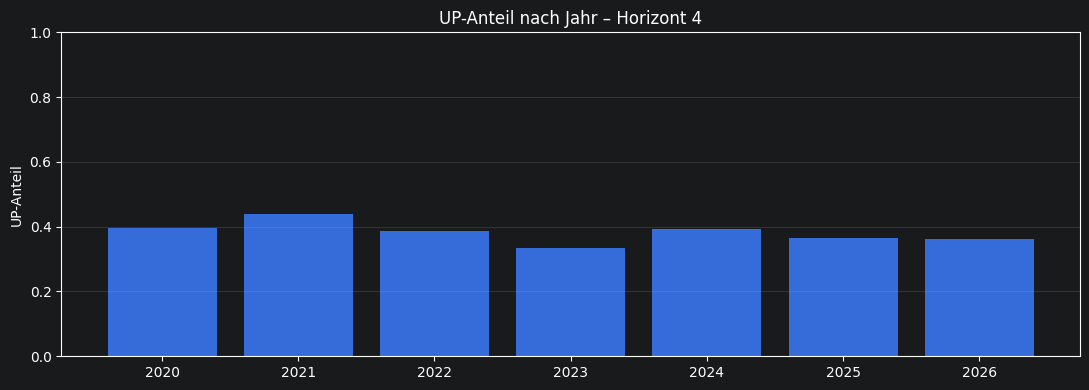

In [14]:
overall_balance, yearly_balance = (
    analyze_target_balance(
        target_df,
        SETTINGS,
        horizons=selected_horizons,
    )
)

display(overall_balance)
display(yearly_balance.head(50))

primary_binary_column = (
    f"{target_prefix}_binary_"
    f"{primary_horizon}"
)

primary_yearly = target_df[
    ["open_time", primary_binary_column]
].copy()
primary_yearly["year"] = (
    primary_yearly["open_time"].dt.year
)

up_ratio_by_year = (
    primary_yearly
    .groupby(
        "year",
        observed=True,
    )[primary_binary_column]
    .mean()
    .reset_index(name="up_ratio")
)

figure, axis = plt.subplots(
    figsize=(11, 4)
)
axis.bar(
    up_ratio_by_year["year"],
    up_ratio_by_year["up_ratio"],
)
axis.set_title(
    f"UP-Anteil nach Jahr – "
    f"Horizont {primary_horizon}"
)
axis.set_ylabel("UP-Anteil")
axis.set_ylim(0, 1)
axis.grid(
    True,
    axis="y",
    alpha=0.25,
)
figure.tight_layout()
display(figure)
plt.close(figure)

## 15. Pfad- und Risikotargets

Für jeden Horizont gelten unter anderem:

- Future-Max-Return ≥ finale Simple-Return,
- Future-Min-Return ≤ finale Simple-Return,
- Future-Max-Drawdown ≤ 0,
- realisierte Volatilität ≥ 0.

In [15]:
path_checks = []

for horizon in selected_horizons:
    simple_column = (
        f"{target_prefix}_return_simple_{horizon}"
    )
    maximum_column = (
        f"{target_prefix}_future_max_return_{horizon}"
    )
    minimum_column = (
        f"{target_prefix}_future_min_return_{horizon}"
    )
    volatility_column = (
        f"{target_prefix}_future_realized_volatility_"
        f"{horizon}"
    )
    annualized_column = (
        f"{target_prefix}_future_realized_volatility_"
        f"annualized_{horizon}"
    )
    drawdown_column = (
        f"{target_prefix}_future_max_drawdown_{horizon}"
    )

    maximum_violation = int(
        (
            target_df[maximum_column]
            + 1e-12
            < target_df[simple_column]
        ).sum()
    )
    minimum_violation = int(
        (
            target_df[minimum_column]
            - 1e-12
            > target_df[simple_column]
        ).sum()
    )
    volatility_violation = int(
        (
            target_df[volatility_column]
            < -1e-12
        ).sum()
    )
    annualized_violation = int(
        (
            target_df[annualized_column]
            < -1e-12
        ).sum()
    )
    drawdown_violation = int(
        (
            target_df[drawdown_column]
            > 1e-12
        ).sum()
    )

    path_checks.append(
        {
            "horizon": horizon,
            "max_return_violations": (
                maximum_violation
            ),
            "min_return_violations": (
                minimum_violation
            ),
            "volatility_violations": (
                volatility_violation
            ),
            "annualized_volatility_violations": (
                annualized_violation
            ),
            "drawdown_violations": (
                drawdown_violation
            ),
            "passed": (
                maximum_violation == 0
                and minimum_violation == 0
                and volatility_violation == 0
                and annualized_violation == 0
                and drawdown_violation == 0
            ),
        }
    )

path_check_frame = pd.DataFrame(
    path_checks
)

display(path_check_frame)
assert path_check_frame["passed"].all()

,horizon,max_return_violations,min_return_violations,volatility_violations,annualized_volatility_violations,drawdown_violations,passed
0,1,0,0,0,0,0,True
1,4,0,0,0,0,0,True
2,16,0,0,0,0,0,True
3,96,0,0,0,0,0,True


## 16. Primärtarget in der jüngsten Marktphase

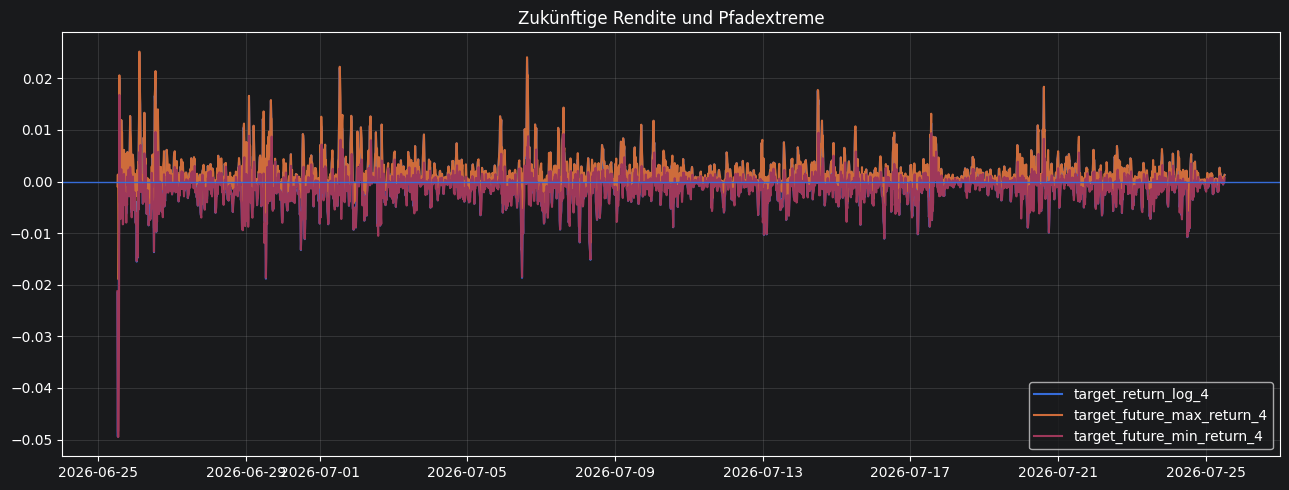

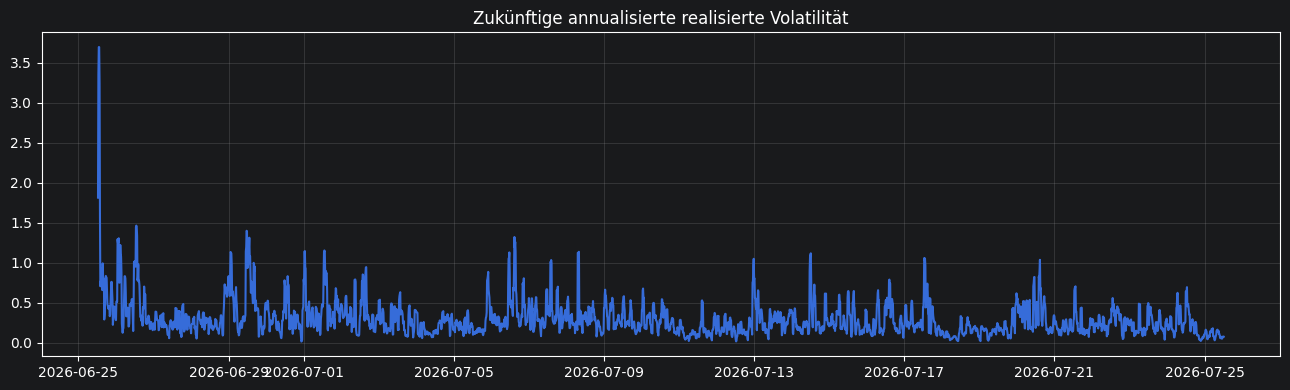

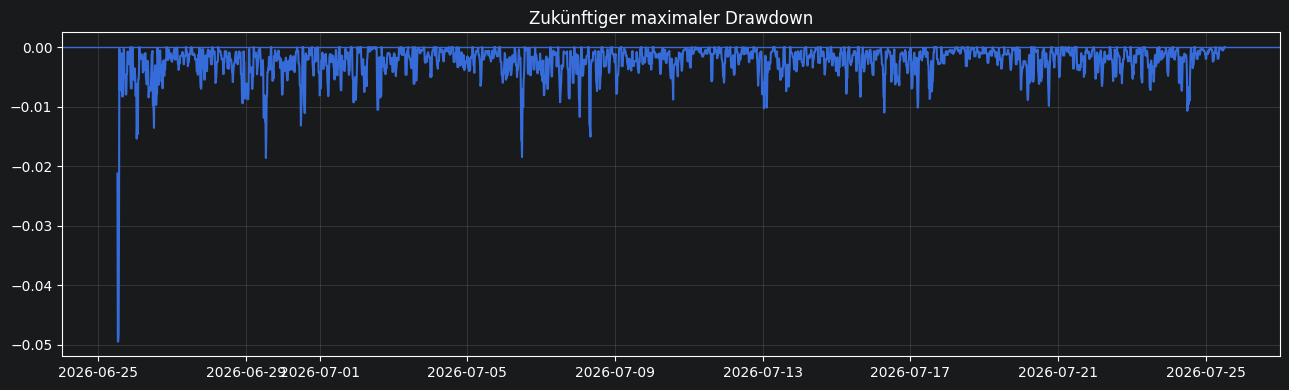

In [16]:
recent = target_df.tail(
    RECENT_CANDLES
).copy()
recent_time = recent["open_time"]

primary_return = (
    f"{target_prefix}_return_log_"
    f"{primary_horizon}"
)
primary_max = (
    f"{target_prefix}_future_max_return_"
    f"{primary_horizon}"
)
primary_min = (
    f"{target_prefix}_future_min_return_"
    f"{primary_horizon}"
)
primary_volatility = (
    f"{target_prefix}_future_realized_volatility_"
    f"annualized_{primary_horizon}"
)
primary_drawdown = (
    f"{target_prefix}_future_max_drawdown_"
    f"{primary_horizon}"
)

figure, axis = plt.subplots(
    figsize=(13, 5)
)
axis.plot(
    recent_time,
    recent[primary_return],
    label=primary_return,
)
axis.plot(
    recent_time,
    recent[primary_max],
    label=primary_max,
)
axis.plot(
    recent_time,
    recent[primary_min],
    label=primary_min,
)
axis.axhline(0, linewidth=1)
axis.set_title(
    "Zukünftige Rendite und Pfadextreme"
)
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
display(figure)
plt.close(figure)

figure, axis = plt.subplots(
    figsize=(13, 4)
)
axis.plot(
    recent_time,
    recent[primary_volatility],
)
axis.set_title(
    "Zukünftige annualisierte realisierte Volatilität"
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
display(figure)
plt.close(figure)

figure, axis = plt.subplots(
    figsize=(13, 4)
)
axis.plot(
    recent_time,
    recent[primary_drawdown],
)
axis.axhline(0, linewidth=1)
axis.set_title(
    "Zukünftiger maximaler Drawdown"
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
display(figure)
plt.close(figure)

## 17. Unvollständige Zukunftsfenster am Datensatzende

Zur Demonstration werden Targets ohne das automatische Entfernen
unvollständiger Zeilen berechnet.

,horizon,missing_target_rows,minimum_expected_tail_rows
0,1,1,1
1,4,4,4
2,16,16,16
3,96,96,96


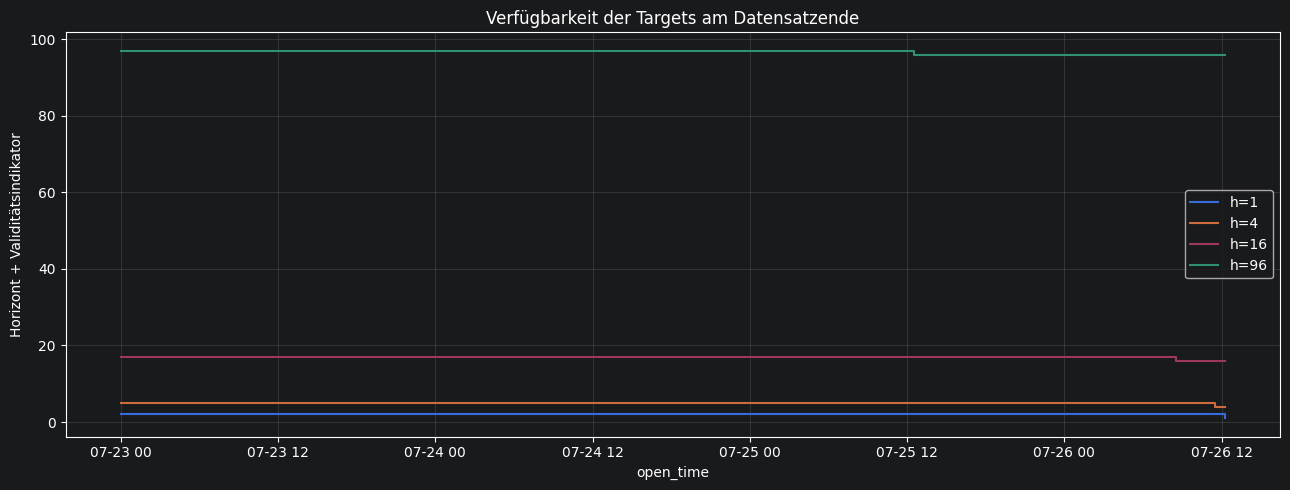

In [17]:
tail_demo_size = (
    max(selected_horizons) * 3
    + 50
)
tail_candles = candle_df.tail(
    tail_demo_size
).copy()

incomplete_tail = build_target_frame(
    tail_candles,
    SETTINGS,
    horizons=selected_horizons,
    drop_incomplete=False,
)

incomplete_rows = []

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_return_log_{horizon}"
    )

    incomplete_rows.append(
        {
            "horizon": horizon,
            "missing_target_rows": int(
                incomplete_tail[column]
                .isna()
                .sum()
            ),
            "minimum_expected_tail_rows": horizon,
        }
    )

incomplete_summary = pd.DataFrame(
    incomplete_rows
)
display(incomplete_summary)

figure, axis = plt.subplots(
    figsize=(13, 5)
)

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_return_log_{horizon}"
    )
    valid = (
        incomplete_tail[column]
        .notna()
        .astype(int)
    )

    axis.step(
        incomplete_tail["open_time"],
        valid + horizon,
        where="post",
        label=f"h={horizon}",
    )

axis.set_title(
    "Verfügbarkeit der Targets am Datensatzende"
)
axis.set_xlabel("open_time")
axis.set_ylabel(
    "Horizont + Validitätsindikator"
)
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
display(figure)
plt.close(figure)

## 18. Datenlückensicherheit

Ein Target darf nur entstehen, wenn Start-, Ziel- und sämtliche
Zwischenkerzen vorhanden sind.

Reale Datenlücke verwendet
Lückenzeitpunkt: 2020-02-09 03:00:00+00:00


,horizon,rows_whose_window_reaches_gap,missing_targets_in_region
0,1,1,0
1,4,1,0
2,16,13,12
3,96,93,92


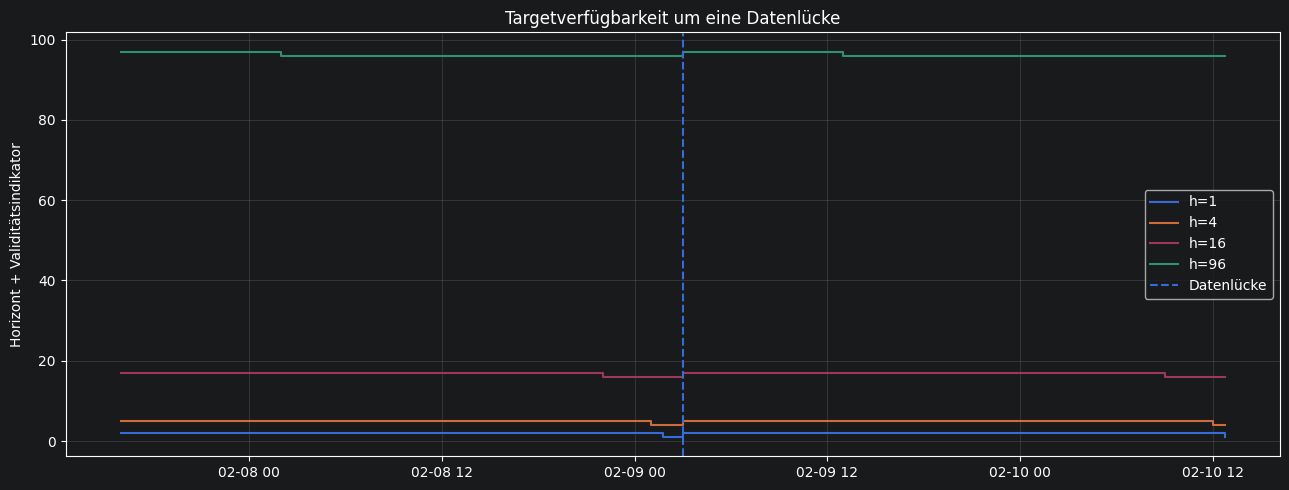

In [18]:
market_candles = (
    candle_df
    .loc[
        (
            candle_df["symbol"]
            == SETTINGS.market.symbol
        )
        & (
            candle_df["interval"]
            == SETTINGS.market.interval
        )
    ]
    .sort_values("open_time")
    .reset_index(drop=True)
    .copy()
)

market_candles["open_time"] = pd.to_datetime(
    market_candles["open_time"],
    utc=True,
)

time_differences = (
    market_candles["open_time"].diff()
)
real_gap_positions = np.flatnonzero(
    time_differences > interval_delta
)

maximum_horizon = max(
    selected_horizons
)
context_radius = (
    maximum_horizon + 40
)

if len(real_gap_positions):
    gap_position = int(
        real_gap_positions[0]
    )
    context_start = max(
        0,
        gap_position - context_radius,
    )
    context_end = min(
        len(market_candles),
        gap_position + context_radius,
    )

    gap_demo_candles = (
        market_candles.iloc[
            context_start:context_end
        ]
        .copy()
        .reset_index(drop=True)
    )

    gap_description = (
        "Reale Datenlücke verwendet"
    )
    gap_time = market_candles.iloc[
        gap_position
    ]["open_time"]
else:
    required_rows = (
        3 * maximum_horizon + 100
    )
    gap_demo_candles = (
        market_candles.head(
            required_rows
        )
        .copy()
        .reset_index(drop=True)
    )

    remove_position = (
        len(gap_demo_candles) // 2
    )
    gap_time = gap_demo_candles.iloc[
        remove_position
    ]["open_time"]

    gap_demo_candles = (
        gap_demo_candles.drop(
            index=remove_position
        )
        .reset_index(drop=True)
    )
    gap_description = (
        "Künstlich entfernte Kerze verwendet"
    )

gap_demo_targets = build_target_frame(
    gap_demo_candles,
    SETTINGS,
    horizons=selected_horizons,
    drop_incomplete=False,
)

gap_rows = []

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_return_log_{horizon}"
    )

    near_gap = (
        gap_demo_targets["open_time"]
        <= gap_time
    ) & (
        gap_demo_targets["open_time"]
        >= (
            gap_time
            - horizon * interval_delta
        )
    )

    gap_rows.append(
        {
            "horizon": horizon,
            "rows_whose_window_reaches_gap": int(
                near_gap.sum()
            ),
            "missing_targets_in_region": int(
                gap_demo_targets.loc[
                    near_gap,
                    column,
                ].isna().sum()
            ),
        }
    )

print(gap_description)
print("Lückenzeitpunkt:", gap_time)
display(pd.DataFrame(gap_rows))

figure, axis = plt.subplots(
    figsize=(13, 5)
)

for horizon in selected_horizons:
    column = (
        f"{target_prefix}_return_log_{horizon}"
    )
    valid = (
        gap_demo_targets[column]
        .notna()
        .astype(int)
    )

    axis.step(
        gap_demo_targets["open_time"],
        valid + horizon,
        where="post",
        label=f"h={horizon}",
    )

axis.axvline(
    gap_time,
    linestyle="--",
    label="Datenlücke",
)
axis.set_title(
    "Targetverfügbarkeit um eine Datenlücke"
)
axis.set_ylabel(
    "Horizont + Validitätsindikator"
)
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
display(figure)
plt.close(figure)

## 19. Alignment, Lokalität und Determinismus

In [19]:
if RUN_SAFETY_TESTS:
    alignment_check = (
        validate_target_alignment(
            target_df,
            candle_df,
            SETTINGS,
            horizons=selected_horizons,
            sample_size=(
                ALIGNMENT_SAMPLE_SIZE
            ),
        )
    )

    locality_check = (
        validate_target_locality(
            candle_df,
            SETTINGS,
            horizons=selected_horizons,
        )
    )

    determinism_check = (
        validate_determinism(
            candle_df,
            SETTINGS,
            horizons=selected_horizons,
        )
    )
else:
    alignment_check = {
        "passed": False,
        "skipped": True,
    }
    locality_check = {
        "passed": False,
        "skipped": True,
    }
    determinism_check = {
        "passed": False,
        "skipped": True,
    }

safety_checks = pd.DataFrame(
    [
        {
            "check": "exact_alignment",
            **alignment_check,
        },
        {
            "check": "target_locality",
            **locality_check,
        },
        {
            "check": "determinism",
            **determinism_check,
        },
    ]
)

display(safety_checks)

if RUN_SAFETY_TESTS:
    assert alignment_check["passed"]
    assert locality_check["passed"]
    assert determinism_check["passed"]

,check,passed,sample_rows,checked_targets,maximum_absolute_error,skipped,first_modified_time,comparison_rows,maximum_horizon,fingerprint
0,exact_alignment,True,2000,"8,000.00000000",0.00000000,NaN,NaN,NaN,NaN,NaN
1,target_locality,True,2048,NaN,NaN,False,2020-01-11T16:00:00+00:00,928.00000000,96.00000000,NaN
2,determinism,True,2048,NaN,NaN,NaN,NaN,NaN,NaN,6dfe6bf88b2c27a48ae7690f608b81ca82c0eea5124a03...


## 20. Korrelation der Return-Targets

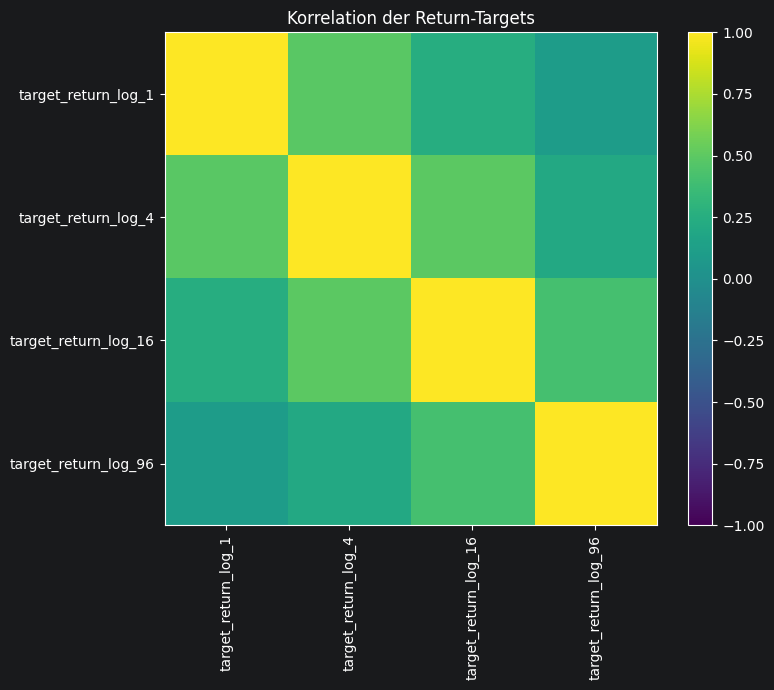

,target_return_log_1,target_return_log_4,target_return_log_16,target_return_log_96
target_return_log_1,1.00000000,0.49090094,0.24657847,0.10166822
target_return_log_4,0.49090094,1.00000000,0.49494811,0.20484301
target_return_log_16,0.24657847,0.49494811,1.00000000,0.41284105
target_return_log_96,0.10166822,0.20484301,0.41284105,1.00000000


In [20]:
return_columns = [
    f"{target_prefix}_return_log_{horizon}"
    for horizon in selected_horizons
]

return_correlation = target_df[
    return_columns
].corr()

figure, axis = plt.subplots(
    figsize=(8, 7)
)
image = axis.imshow(
    return_correlation.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)
axis.set_xticks(
    range(len(return_columns))
)
axis.set_xticklabels(
    return_columns,
    rotation=90,
)
axis.set_yticks(
    range(len(return_columns))
)
axis.set_yticklabels(
    return_columns,
)
axis.set_title(
    "Korrelation der Return-Targets"
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
display(figure)
plt.close(figure)

display(return_correlation)

## 21. Zeitliche Stabilität der Targets

target_return_log_1                        target_return_log_4                        target_return_log_16                        target_return_log_96                       
                    mean        std      median                mean        std      median                 mean        std      median                 mean        std      median
year                                                                                                                                                                              
2020          0.00003821 0.00409268  0.00004831          0.00015246 0.00790476  0.00013694           0.00061527 0.01493486  0.00056199           0.00371540 0.03717186  0.00344926
2021          0.00001468 0.00493750 -0.00001203          0.00005900 0.00953588  0.00009096           0.00023436 0.01849464  0.00022363           0.00105530 0.04388152  0.00154620
2022         -0.00002943 0.00342013  0.00000723         -0.00011807 0.00687874  0.00001089          -0.00047434 0.01354301 -0.00007228          -0.00286542 0.03321195 -0.00141972
2023          0.00002633 0.00230558  0.00001104          0.00010530 0.00447068  0.00004416           0.00043214 0.00896857  0.00011011           0.00266578 0.02311829  0.00073078
2024          0.00002250 0.00283093  0.00001687          0.00009040 0.00563361  0.00007235           0.00036103 0.01104454  0.00033950           0.00214885 0.02674632  0.00166304
2025         -0.00000186 0.00238414 -0.00000043         -0.00000774 0.00471719  0.00003478          -0.00003014 0.00940679  0.00012580          -0.00018030 0.02224523  0.00053104
2026         -0.00001592 0.00251204 -0.00001394         -0.00006365 0.00491131 -0.00000862          -0.00025507 0.00951662 -0.00009878          -0.00152016 0.02318585 -0.00033486

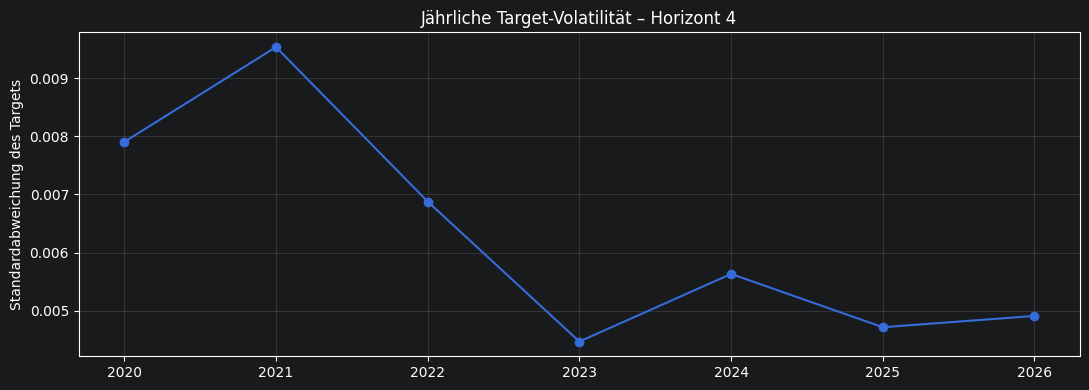

In [21]:
stability = target_df[
    ["open_time", *return_columns]
].copy()

stability["year"] = (
    stability["open_time"].dt.year
)

yearly_statistics = (
    stability
    .groupby(
        "year",
        observed=True,
    )[return_columns]
    .agg(["mean", "std", "median"])
)

display(yearly_statistics)

primary_return_column = (
    f"{target_prefix}_return_log_"
    f"{primary_horizon}"
)

yearly_primary = (
    stability
    .groupby(
        "year",
        observed=True,
    )[primary_return_column]
    .agg(["mean", "std", "median"])
    .reset_index()
)

figure, axis = plt.subplots(
    figsize=(11, 4)
)
axis.plot(
    yearly_primary["year"],
    yearly_primary["std"],
    marker="o",
)
axis.set_title(
    "Jährliche Target-Volatilität – "
    f"Horizont {primary_horizon}"
)
axis.set_ylabel(
    "Standardabweichung des Targets"
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
display(figure)
plt.close(figure)

## 22. Abschließendes Freigabegate

In [22]:
target_values = target_df[
    value_target_columns
]
numeric_values = (
    target_values.to_numpy(
        dtype="float64",
        na_value=np.nan,
        copy=True,
    )
)

binary_valid = all(
    set(
        pd.to_numeric(
            target_df[
                f"{target_prefix}_binary_{horizon}"
            ],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .unique()
    ).issubset({0, 1})
    for horizon in selected_horizons
)

multiclass_valid = all(
    set(
        pd.to_numeric(
            target_df[
                f"{target_prefix}_multiclass_{horizon}"
            ],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .unique()
    ).issubset({-1, 0, 1})
    for horizon in selected_horizons
)

release_checks = pd.DataFrame(
    [
        {
            "check": "Candle-Qualitätsgate",
            "passed": quality_report.is_valid,
        },
        {
            "check": "Target-Validierung",
            "passed": target_report.is_valid,
        },
        {
            "check": (
                "Keine fehlenden Targetwerte"
            ),
            "passed": (
                int(
                    target_values
                    .isna()
                    .sum()
                    .sum()
                )
                == 0
            ),
        },
        {
            "check": (
                "Keine unendlichen Targetwerte"
            ),
            "passed": (
                int(
                    np.isinf(
                        numeric_values
                    ).sum()
                )
                == 0
            ),
        },
        {
            "check": (
                "Exakte Target-Endzeiten"
            ),
            "passed": (
                horizon_check_frame[
                    "passed"
                ].all()
            ),
        },
        {
            "check": (
                "Korrekte manuelle Renditen"
            ),
            "passed": (
                return_check_frame[
                    "passed"
                ].all()
            ),
        },
        {
            "check": (
                "Gültige Binärklassen"
            ),
            "passed": binary_valid,
        },
        {
            "check": (
                "Gültige Multiclass-Werte"
            ),
            "passed": multiclass_valid,
        },
        {
            "check": (
                "Konsistente Pfadtargets"
            ),
            "passed": (
                path_check_frame[
                    "passed"
                ].all()
            ),
        },
        {
            "check": (
                "Chronologisch sortiert"
            ),
            "passed": (
                target_df["open_time"]
                .is_monotonic_increasing
            ),
        },
        {
            "check": (
                "Keine doppelten Schlüssel"
            ),
            "passed": (
                not target_df.duplicated(
                    [
                        "symbol",
                        "interval",
                        "open_time",
                    ]
                ).any()
            ),
        },
        {
            "check": "Exaktes Alignment",
            "passed": bool(
                alignment_check.get(
                    "passed"
                )
            ),
        },
        {
            "check": "Zeitliche Lokalität",
            "passed": bool(
                locality_check.get(
                    "passed"
                )
            ),
        },
        {
            "check": "Determinismus",
            "passed": bool(
                determinism_check.get(
                    "passed"
                )
            ),
        },
    ]
)

display(release_checks)

assert release_checks["passed"].all(), (
    "Target-Freigabegate fehlgeschlagen."
)

display(
    Markdown(
        f"""
### Ergebnis

Der Target-Datensatz ist für den Dataset Builder freigegeben.

- **Candle-Zeilen:** {len(candle_df):,}
- **Target-Zeilen:** {len(target_df):,}
- **Werttargets:** {len(value_target_columns):,}
- **Horizonte:** {selected_horizons}
- **Primärhorizont:** {primary_horizon}
- **Beginn:** {target_df["open_time"].min()}
- **Ende:** {target_df["open_time"].max()}

"""
    )
)

,check,passed
0,Candle-Qualitätsgate,True
1,Target-Validierung,True
2,Keine fehlenden Targetwerte,True
3,Keine unendlichen Targetwerte,True
4,Exakte Target-Endzeiten,True
5,Korrekte manuelle Renditen,True
6,Gültige Binärklassen,True
7,Gültige Multiclass-Werte,True
8,Konsistente Pfadtargets,True
9,Chronologisch sortiert,True



### Ergebnis

Der Target-Datensatz ist für den Dataset Builder freigegeben.

- **Candle-Zeilen:** 230,106
- **Target-Zeilen:** 228,570
- **Werttargets:** 40
- **Horizonte:** (1, 4, 16, 96)
- **Primärhorizont:** 4
- **Beginn:** 2020-01-01 00:00:00+00:00
- **Ende:** 2026-07-25 12:15:00+00:00

Der nächste Schritt ist die Zusammenführung durch
`dataset_builder.py`.
